In [ ]:
%cd C:/Users/micha/Documents/master_thesis
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
from torch.utils.tensorboard import SummaryWriter
import os
from datetime import datetime
from tqdm import tqdm
import itertools
import pandas as pd
from sklearn.model_selection import ParameterGrid
import torch.nn.functional as F
from copy import deepcopy
import math
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, ReduceLROnPlateau, LambdaLR

C:\Users\micha\Documents\master_thesis


In [12]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
class Ship:
    def __init__(self, starting_pos, random_start, max_speed, hp_max, range, stockpile_max):
        self.random_start = random_start
        self.starting_position = starting_pos
        self.starting_hp = hp_max
        self.position = starting_pos
        self.course = 0
        self.speed = 0
        self.max_speed = max_speed
        self.hp = hp_max
        self.alive = True
        self.range = range
        self.stockpile_max = stockpile_max
        self.stockpile = stockpile_max
    
    def move(self, action, dt):
        speed_frac, course_scalar = action[:2]
        self.speed  = np.clip(speed_frac, 0.0, 1.0) * self.max_speed
        self.course = (np.clip(course_scalar, -1.0, 1.0) + 1.0) * np.pi
        self.position += np.array([self.speed * np.cos(self.course) * dt, self.speed * np.sin(self.course) * dt])
        np.clip(self.position, -1.0, 1.0, out=self.position)
        
    def take_damage(self, damage):
        self.hp -= damage
        if self.hp <= 0:
            self.alive = False
            
    def reset(self):
        if self.random_start:
            self.position = np.random.uniform(-1.0, 1.0, size=2)
        else:
            self.position = self.starting_position
        self.hp = self.starting_hp
        self.stockpile = self.stockpile_max
        self.course = 0
        self.speed = 0
        self.alive = True

def build_scheduler(optimizer, kind: str, **kw):
    kind = kind.lower()

    if kind in ("constant", "fixed", "none"):
        return LambdaLR(optimizer, lr_lambda=lambda step: 1.0)

    if kind == "step":
        return StepLR(optimizer, step_size=kw.get("step_size", 10_000),
                                gamma     =kw.get("gamma",     0.5))

    if kind == "exp":
        return ExponentialLR(optimizer, gamma=kw.get("gamma", 0.99))

    if kind == "cosine":
        return CosineAnnealingLR(optimizer,
                                T_max = kw["T_max"],
                                eta_min = kw.get("eta_min", 1e-6))

    if kind == "plateau":
        return ReduceLROnPlateau(optimizer,
                                mode      = kw.get("mode", "min"),
                                patience  = kw.get("patience", 20_000),
                                factor    = kw.get("factor", 0.5),
                                min_lr    = kw.get("min_lr", 1e-6))
    return None          # No scheduling requested

class BaseNoise:
    def reset(self): 
        pass

    def __call__(self):
        raise NotImplementedError

class GaussianNoise(BaseNoise):
    def __init__(self, dim, sigma):
        self.dim   = dim
        self.sigma = sigma

    def __call__(self):
        return self.sigma * np.random.randn(self.dim)

class OUNoise(BaseNoise):
    def __init__(self, dim, theta=0.15, sigma=0.2, dt=1e-2):
        self.dim   = dim
        self.theta = theta
        self.sigma = sigma
        self.dt    = dt
        self.reset()

    def reset(self):
        self.state = np.zeros(self.dim, dtype=np.float32)

    def __call__(self):
        dx = self.theta * (-self.state) * self.dt \
             + self.sigma * np.sqrt(self.dt) * np.random.randn(self.dim)
        self.state += dx
        return self.state

class EpsilonGreedyNoise(BaseNoise):
    def __init__(self, dim, epsilon):
        self.dim     = dim
        self.epsilon = epsilon
        
    def __call__(self):
        if np.random.rand() < self.epsilon:
            return np.random.uniform(-1.0, 1.0, size=self.dim)
        return np.zeros(self.dim, dtype=np.float32)

class CompositeNoise(BaseNoise):
    def __init__(self, *sources):
        assert sources, "need at least one noise source"
        self.sources = sources
        self.dim     = sources[0].dim
        # sanity check
        for s in self.sources:
            if s.dim != self.dim:
                raise ValueError("all noise sources must share the same `dim`")

    def reset(self):
        for s in self.sources:
            if hasattr(s, "reset"):
                s.reset()

    def __call__(self):
        out = np.zeros(self.dim, dtype=np.float32)
        for s in self.sources:
            out += s()
        return out

def make_noise(kind, dim=None, **kw):
    kind = kind.lower()
    
    if kind in ("decay", "annealed", "exp-decay"):
        # build the *base* noise first
        base_spec = kw["base"]                    # a dict with its own 'kind'
        base_kind = base_spec["kind"]
        base_dim  = base_spec.get("dim", dim)
        base_kw   = {k: v for k, v in base_spec.items()
                            if k not in ("kind", "dim")}      # ← drop duplicate
        base      = make_noise(base_kind, base_dim, **base_kw)

        return ExpDecayNoise(
            base_noise = base,
            scale_init = kw.get("scale_init", 1.0),
            gamma      = kw.get("gamma",      0.999),
            scale_min  = kw.get("scale_min",  0.05),
            per        = kw.get("per",        "step")   # ← default unchanged
            )
    # ---------------------------------------------------- old entries
    if kind in ("gauss", "gaussian", "normal"):
        return GaussianNoise(dim, sigma=kw.get("sigma", 0.1))

    if kind in ("ou", "ornstein-uhlenbeck"):
        return OUNoise(dim,
                        theta = kw.get("theta", 0.15),
                        sigma = kw.get("sigma", 0.2),
                        dt    = kw.get("dt",    1e-2))

    if kind in ("eps", "epsilon", "epsilon-greedy"):
        return EpsilonGreedyNoise(dim, epsilon=kw.get("epsilon", 0.1))

    # ---------------------------------------------------- combine several
    if kind in ("combo", "composite"):
        parts = kw["parts"]                      # list of **dicts**
        sources = []
        for spec in parts:
            k = spec["kind"]
            src_dim = spec.get("dim", dim)      # fall back to global dim
            # Make a *copy* of spec minus 'kind' to avoid side-effects
            spec_kw = {kk: vv for kk, vv in spec.items() if kk != "kind"}
            sources.append(make_noise(k, src_dim, **spec_kw))
        return CompositeNoise(*sources)

    raise ValueError(f"Unknown noise kind '{kind}'")

class ExpDecayNoise(BaseNoise):
    def __init__(self, base_noise, scale_init=1.0,
                    gamma=0.999, scale_min=0.05, per="step"):
        self.n         = base_noise
        self.scale     = scale_init
        self.gamma     = gamma
        self.scale_min = scale_min
        assert per in ("step", "episode")
        self.per       = per
        self.dim       = self.n.dim

    # ------------------------------------------------------------------ #
    def reset(self):
        self.n.reset()
        if self.per == "episode":                     # decay **here**
            self.scale = max(self.scale * self.gamma, self.scale_min)

    # ------------------------------------------------------------------ #
    def __call__(self):
        out = self.n() * self.scale
        if self.per == "step":                        # decay each step
            self.scale = max(self.scale * self.gamma, self.scale_min)
        return out

class RunningMeanStd:
    def __init__(self, shape, epsilon: float = 1e-4, dtype=np.float64):
        self.mean  = np.zeros(shape, dtype=dtype)
        self.var   = np.ones(shape,  dtype=dtype)
        self.count = epsilon                      # protects against /0

    # ------------------------------------------------------------------ #
    def update(self, x: np.ndarray):
        x          = np.asarray(x, dtype=self.mean.dtype)
        batch_mean = x.mean(axis=0)
        batch_var  = x.var(axis=0)
        batch_cnt  = x.shape[0]

        delta       = batch_mean - self.mean
        tot_count   = self.count + batch_cnt

        # updated mean
        new_mean    = self.mean + delta * batch_cnt / tot_count

        # pooled variance (Chan et al. 1979)
        m_a = self.var * self.count
        m_b = batch_var * batch_cnt
        M2  = m_a + m_b + delta**2 * self.count * batch_cnt / tot_count
        new_var = M2 / tot_count

        # assign back
        self.mean   = new_mean
        self.var    = new_var
        self.count  = tot_count

    # ------------------------------------------------------------------ #
    def normalize(self, x, clip=None):
        x = (x - self.mean) / (np.sqrt(self.var) + 1e-8)
        if clip is not None:
            x = np.clip(x, -clip, clip)
        return x

    # Convenience ------------------------------------------------------- #
    @property
    def std(self):
        return np.sqrt(self.var)
    
def scalar_to_intshots(f, max_shots):
    return int(np.clip(np.round(f * max_shots), 0, max_shots))

def scalar_to_index(u, n):
    return int(np.clip(np.round(0.5 * (u + 1) * (n - 1)), 0, n - 1))

def lennard_jones(D, sigma, epsilon, n=4, m=2):
    return -epsilon * ((sigma / D) ** n - (sigma / D) ** m)

def lj_supremacy_reward(pos_A, pos_B, cfg_A, cfg_B):
    D = np.linalg.norm(pos_A[:, None, :] - pos_B[None, :, :], axis=-1) + 1e-3
    w_sup = cfg_A.get("w_sup", 0.5)
    sigma_sup = np.sqrt(2) * w_sup
    R_sup_A = cfg_A.get("R_sup", 1.0)
    R_sup_B = cfg_B.get("R_sup", 1.0)
    r_sup_A = lennard_jones(D, sigma_sup, R_sup_A, n=4, m=2).sum(axis=1)
    r_sup_B = lennard_jones(D, sigma_sup, R_sup_B, n=4, m=2).sum(axis=0)
    return r_sup_A, r_sup_B

def lj_formation_reward(pos_A, pos_B, cfg_A, cfg_B):
    D_aa = np.linalg.norm(pos_A[:, None, :] - pos_A[None, :, :], axis=-1) + 1e-3
    D_bb = np.linalg.norm(pos_B[:, None, :] - pos_B[None, :, :], axis=-1) + 1e-3
    np.fill_diagonal(D_aa, np.inf)
    np.fill_diagonal(D_bb, np.inf)
    D_form = cfg_A.get("D_form", 0.5)
    sigma_form = np.sqrt(2) * D_form
    R_form_A = cfg_A.get("R_form", 1.0)
    R_form_B = cfg_B.get("R_form", 1.0)
    r_form_A = lennard_jones(D_aa, sigma_form, R_form_A, n=4, m=2).sum(axis=1)
    r_form_B = lennard_jones(D_bb, sigma_form, R_form_B, n=4, m=2).sum(axis=1)
    return r_form_A, r_form_B

def predictive_intercept_reward(pos_A, pos_B, vel_A, vel_B, cfg_A, cfg_B):
    eps = 1e-3
    v_i_max_A = cfg_A.get("v_max", 0.6)
    R_pred_A = cfg_A.get("R_pred", 1.0)
    intercept_time_A = np.linalg.norm(pos_B[None, :, :] - pos_A[:, None, :], axis=-1) / (v_i_max_A + eps)
    future_B = pos_B[None, :, :] + intercept_time_A[:, :, None] * vel_B[None, :, :]
    pred_dist_A = np.linalg.norm(future_B - pos_A[:, None, :], axis=-1) + eps
    r_pred_A = -R_pred_A * pred_dist_A.sum(axis=1)

    v_i_max_B = cfg_B.get("v_max", 0.6)
    R_pred_B = cfg_B.get("R_pred", 1.0)
    intercept_time_B = np.linalg.norm(pos_A[None, :, :] - pos_B[:, None, :], axis=-1) / (v_i_max_B + eps)
    future_A = pos_A[None, :, :] + intercept_time_B[:, :, None] * vel_A[None, :, :]
    pred_dist_B = np.linalg.norm(future_A - pos_B[:, None, :], axis=-1) + eps
    r_pred_B = -R_pred_B * pred_dist_B.sum(axis=1)

    return r_pred_A, r_pred_B


In [ ]:
class NavalEnvironment(gym.Env):
    def __init__(self, fleet_alice, fleet_bob, max_steps, agent_cfgs, meet_dist = 0.1, dt = 0.05, max_shots = 3):
        super().__init__()
        self.fleet_alice   = fleet_alice
        self.fleet_bob     = fleet_bob
        self.max_steps  = max_steps
        self.step_count = 0
        self.meet_dist  = meet_dist
        self.dt         = dt
        self.n_alice    = len(fleet_alice)
        self.n_bob      = len(fleet_bob)
        
        # list of two dicts, one per agent
        self.cfg_alice  = agent_cfgs[0]
        self.cfg_bob    = agent_cfgs[1]
        
        low_pr_ship = [0.0, -1.0]
        high_pr_ship = [1.0, 1.0]
        
        # Define action and state spaces
        action_low  = np.tile(low_pr_ship, self.n_alice + self.n_bob).astype(np.float32)
        action_high = np.tile(high_pr_ship, self.n_alice + self.n_bob).astype(np.float32)
        self.action_space = gym.spaces.Box(action_low, action_high, dtype=np.float32)

        self.state_space = gym.spaces.Box(-1.0, 1.0, shape=(2 * (self.n_alice + self.n_bob),), dtype=np.float32)

    def reset(self, random_start=False):
        for ship in self.fleet_alice + self.fleet_bob:
            ship.reset()
        self.step_count = 0
        return self._get_state()

    def _get_state(self):
        pos_alice = np.stack([ship.position for ship in self.fleet_alice])  # (nA,2)
        pos_bob   = np.stack([ship.position for ship in self.fleet_bob])    # (nB,2)
        return np.concatenate([pos_alice.ravel(), pos_bob.ravel()]).astype(np.float32)

    def step(self, action):
        # Unpack action vector
        action = action.reshape(-1, 2)
        action_alice = action[:self.n_alice]
        action_bob   = action[self.n_alice:]
        
        # Movement
        for ship, move_order in zip(self.fleet_alice, action_alice):
            if ship.alive:
                ship.move(move_order[:2], self.dt)

        for ship, move_order in zip(self.fleet_bob, action_bob):
            if ship.alive:
                ship.move(move_order[:2], self.dt)

        self.step_count += 1

        # Update state
        pos_alice = np.stack([s.position for s in self.fleet_alice])
        pos_bob   = np.stack([s.position for s in self.fleet_bob])
        distance_matrix = np.linalg.norm(pos_alice[:, None, :] - pos_bob[None, :, :], axis=-1)

        # Rewards
        # Attractive term to closest opponent
        r_ship_A = -distance_matrix.sum(axis=1) * self.cfg_alice.get("r_attract")
        r_ship_B = -distance_matrix.sum(axis=0) * self.cfg_bob.get("r_attract")

        # Velocity vectors for predictive reward
        vel_alice = np.stack([
            ship.speed * np.array([np.cos(ship.course), np.sin(ship.course)])
            for ship in self.fleet_alice
        ])
        vel_bob = np.stack([
            ship.speed * np.array([np.cos(ship.course), np.sin(ship.course)])
            for ship in self.fleet_bob
        ])

        # 1. Lennard-Jones Supremacy Reward
        r_lj_sup_A, r_lj_sup_B = lj_supremacy_reward(pos_alice, pos_bob, self.cfg_alice, self.cfg_bob)
        r_ship_A += self.cfg_alice.get("r_lj_sup", 0.0) * r_lj_sup_A
        r_ship_B += self.cfg_bob.get("r_lj_sup", 0.0) * r_lj_sup_B

        # 2. Lennard-Jones Formation Reward (same-fleet interaction)
        r_lj_form_A, r_lj_form_B = lj_formation_reward(pos_alice, pos_bob, self.cfg_alice, self.cfg_bob)
        r_ship_A += self.cfg_alice.get("r_lj_form", 0.0) * r_lj_form_A
        r_ship_B += self.cfg_bob.get("r_lj_form", 0.0) * r_lj_form_B

        # 3. Predictive Intercept Reward
        r_pred_A, r_pred_B = predictive_intercept_reward(pos_alice, pos_bob, vel_alice, vel_bob, self.cfg_alice, self.cfg_bob)
        r_ship_A += self.cfg_alice.get("r_pred", 0.0) * r_pred_A
        r_ship_B += self.cfg_bob.get("r_pred", 0.0) * r_pred_B

        # Wall penalty
        wall_th_A = self.cfg_alice.get("wall_threshold", 0.0)
        if wall_th_A > 0:
            dist_wall_A = np.minimum.reduce([np.abs(pos_alice[:,0] - 1),
                                            np.abs(pos_alice[:,0] + 1),
                                            np.abs(pos_alice[:,1] - 1),
                                            np.abs(pos_alice[:,1] + 1)])
            viol_A = np.clip(wall_th_A - dist_wall_A, 0.0, None)
            r_ship_A += viol_A * self.cfg_alice.get("wall_penalty", 0.0)

        wall_th_B = self.cfg_bob.get("wall_threshold", 0.0)
        if wall_th_B > 0:
            dist_wall_B = np.minimum.reduce([np.abs(pos_bob[:,0] - 1),
                                            np.abs(pos_bob[:,0] + 1),
                                            np.abs(pos_bob[:,1] - 1),
                                            np.abs(pos_bob[:,1] + 1)])
            viol_B = np.clip(wall_th_B - dist_wall_B, 0.0, None)
            r_ship_B += viol_B * self.cfg_bob.get("wall_penalty", 0.0)

        # Time penalty
        r_ship_A += self.cfg_alice.get("time_penalty", 0.0)
        r_ship_B += self.cfg_bob.get("time_penalty", 0.0)

        # Speed reward
        reward_A = r_ship_A.mean()
        reward_B = r_ship_B.mean()
        reward_A += self.cfg_alice.get("speed_reward")*action_alice[:, 0].mean()
        reward_B += self.cfg_bob.get("speed_reward")*action_bob[:, 0].mean()
        
        # Firing mechanics, set to automatic
        pending_damage_bob = np.zeros(self.n_bob,    dtype=np.float32)
        pending_damage_alice   = np.zeros(self.n_alice,  dtype=np.float32)

        # Alice firing
        for i, ship in enumerate(self.fleet_alice):
            if ship.alive and ship.stockpile > 0:
                # Mask who is in range
                in_rng = np.where(distance_matrix[i] <= ship.range)[0]
                if in_rng.size:
                    # shoot the closest
                    tgt = in_rng[np.argmin(distance_matrix[i, in_rng])]
                    pending_damage_bob[tgt] += 1
                    ship.stockpile           -= 1
                    reward_A += self.cfg_alice.get("reward_fire")

        # Bob firing
        for j, ship in enumerate(self.fleet_bob):
            if ship.alive and ship.stockpile > 0:
                in_rng = np.where(distance_matrix[:, j] <= ship.range)[0]
                if in_rng.size:
                    tgt = in_rng[np.argmin(distance_matrix[in_rng, j])]
                    pending_damage_alice[tgt] += 1
                    ship.stockpile          -= 1
                    reward_B += self.cfg_bob.get("reward_fire")

        # Apply damage after firing solution
        for idx, dmg in enumerate(pending_damage_bob):
            if dmg > 0: self.fleet_bob[idx].take_damage(dmg)
        for idx, dmg in enumerate(pending_damage_alice):
            if dmg > 0: self.fleet_alice[idx].take_damage(dmg)
                                
        rewards  = np.array([reward_A, reward_B], dtype=np.float32)
        
        # Check for alive flags
        alive_alice = [s.alive for s in self.fleet_alice]
        alive_bob = [s.alive for s in self.fleet_bob]
        
        fleet_alice_dead = not any(alive_alice)
        fleet_bob_dead = not any(alive_bob)

        # Termination criteria
        done = (
            fleet_alice_dead or
            fleet_bob_dead or
            (self.step_count >= self.max_steps)
        )

        # Apply victory bonus
        if done:
            if fleet_alice_dead:
                rewards[1] += self.cfg_alice.get("victory_bonus")
            if fleet_bob_dead:
                rewards[0] += self.cfg_bob.get("victory_bonus")

        return self._get_state(), rewards, done, {}


In [ ]:
class Actor(nn.Module):
    # Set up actor network
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, 128),       
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.ReLU(),
            nn.Linear(128, action_dim), 
            nn.Tanh()
        )
        
    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    # Set up critic network
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 128), 
            nn.ReLU(),
            nn.Linear(128, 128),       
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=-1))

class MemoryBuffer:
    # Set up memory buffer
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)
        
    def add(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))
        
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            torch.as_tensor(np.array(s,  dtype=np.float32)),
            torch.as_tensor(np.array(a,  dtype=np.float32)),
            torch.as_tensor(np.array(r,  dtype=np.float32).reshape(-1, 1)),
            torch.as_tensor(np.array(ns, dtype=np.float32)),
            torch.as_tensor(np.array(d,  dtype=np.float32).reshape(-1, 1))
        )
        
    def __len__(self):
        return len(self.buffer)

class DDPGAgent:
    # Set up DDPG agent class
    def __init__(self, state_dim, action_dim, lr_actor, lr_critic, gamma, tau, schedule_actor, schedule_critic, noise_cfg, normalize=False, state_rms=None, reward_rms=None):
        # Initialize networks and copy on to targets
        self.actor = Actor(state_dim, action_dim)
        self.actor_target = deepcopy(self.actor)

        self.critic1 = Critic(state_dim, action_dim)
        self.critic1_target = deepcopy(self.critic1)

        self.critic2 = Critic(state_dim, action_dim)
        self.critic2_target = deepcopy(self.critic2)

        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic1_optim = torch.optim.Adam(self.critic1.parameters(), lr=lr_critic)
        self.critic2_optim = torch.optim.Adam(self.critic2.parameters(), lr=lr_critic)
        
        # Build learning schedulers
        self.actor_scheduler = build_scheduler(self.actor_optim, **schedule_actor)
        self.critic_scheduler = build_scheduler(self.critic1_optim, **schedule_critic)

        # Build noise schedule
        self.noise = make_noise(**noise_cfg)

        # Twin delayed policy smoothing params
        self.policy_delay = 2
        self.policy_noise = 0.1  # reduced from 0.2
        self.noise_clip = 0.5    # reduced from 0.5
        self.train_step = 0

        self.memory_buffer = MemoryBuffer()
        self.normalize = normalize
        self.state_rms = state_rms
        self.reward_rms = reward_rms

        self.gamma = gamma
        self.tau = tau

        self.last_actor_loss = 0.0
        self.last_critic_loss = 0.0
        self.last_q_value = 0.0
        
    def normalize_obs(self, obs_tensor):
        # Normalization of state method
        if not self.normalize or self.state_rms is None:
            return obs_tensor
        obs_np = obs_tensor.cpu().numpy()
        normed = self.state_rms.normalize(obs_np)
        return torch.as_tensor(normed, dtype=torch.float32, device=obs_tensor.device)

    def normalize_reward(self, reward_tensor):
        # Normalization of reward method
        if not self.normalize or self.reward_rms is None:
            return reward_tensor
        rew_np = reward_tensor.cpu().numpy()
        normed = self.reward_rms.normalize(rew_np)
        normed = np.clip(normed, -1.0, 1.0)
        return torch.as_tensor(normed, dtype=torch.float32, device=reward_tensor.device)

    def store_transition(self, s, a, r, ns, d):
        self.memory_buffer.add(s, a, r, ns, d)

    def select_action(self, state):
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        action = self.actor(state_t).detach().numpy()[0]
        noise = self.noise()
        action += noise
        self.last_noise = noise
        return np.clip(action, -1.0, 1.0)

    def train(self, batch_size=64):
        states, actions, rewards, next_s, dones = self._sample_exact(self.memory_buffer, batch_size)

        # Normalize as training progresses
        states  = self.normalize_obs(states)
        next_s  = self.normalize_obs(next_s)
        rewards = self.normalize_reward(rewards)

        # Shuffle for stability
        perm = torch.randperm(batch_size)
        states, actions, rewards, next_s, dones = \
            states[perm], actions[perm], rewards[perm], next_s[perm], dones[perm]

        # Compute target Q value with dual critics
        with torch.no_grad():
            noise = (torch.randn_like(actions) * self.policy_noise) \
                    .clamp(-self.noise_clip, self.noise_clip)
            next_actions = (self.actor_target(next_s) + noise) \
                            .clamp(-1.0, 1.0)

            q1_next = self.critic1_target(next_s, next_actions)
            q2_next = self.critic2_target(next_s, next_actions)
            target_q = rewards + self.gamma * (1 - dones) * torch.min(q1_next, q2_next)

        # Update critics
        current_q1 = self.critic1(states, actions)
        current_q2 = self.critic2(states, actions)

        critic1_loss = F.smooth_l1_loss(current_q1, target_q)
        critic2_loss = F.smooth_l1_loss(current_q2, target_q)

        self.critic1_optim.zero_grad()
        critic1_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic1.parameters(), max_norm=1.0)
        self.critic1_optim.step()

        self.critic2_optim.zero_grad()
        critic2_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic2.parameters(), max_norm=1.0)
        self.critic2_optim.step()

        if self.critic_scheduler is not None:
            metric = (critic1_loss.item()
                        if isinstance(self.critic_scheduler,
                                    torch.optim.lr_scheduler.ReduceLROnPlateau)
                        else None)
            self.critic_scheduler.step(metric)

        self.last_critic_loss = 0.5 * (critic1_loss.item() + critic2_loss.item())
        self.last_q_value     = current_q1.mean().item()
        
        # Update actor every 2 steps with policy smoothing
        if self.train_step % self.policy_delay == 0:
            policy_actions = self.actor(states)
            action_reg = (policy_actions ** 2).mean()
            actor_loss = -self.critic1(states, policy_actions).mean() \
                         + 1e-3 * action_reg

            self.actor_optim.zero_grad()
            actor_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.actor.parameters(),
                                        max_norm=1.0)
            self.actor_optim.step()

            if self.actor_scheduler is not None:
                metric = (actor_loss.item()
                            if isinstance(self.actor_scheduler,
                                        torch.optim.lr_scheduler.ReduceLROnPlateau)
                            else None)
                self.actor_scheduler.step(metric)

            self.last_actor_loss = actor_loss.item()

            # soft‐update targets
            self.soft_update(self.actor_target,  self.actor,  self.tau)
            self.soft_update(self.critic1_target, self.critic1, self.tau)
            self.soft_update(self.critic2_target, self.critic2, self.tau)

        self.train_step += 1


    def soft_update(self, target, source, tau):
        for t_param, s_param in zip(target.parameters(), source.parameters()):
            t_param.data.copy_(tau * s_param.data + (1 - tau) * t_param.data)


In [ ]:
# Agent configurations
cfg_alice = {
    #Rewards
    "r_attract":            3,   # multiplies the −d term
    "r_lj_sup":             1.0, #Superior lj weapon potential
    "r_lj_form":            0.5, #Formation lj potential
    "r_pred":               0.0, #Predictive intercept reward
    "formation_dist":       0.1,  #Optimal formation distance
    "supremacy_range":      1.0, #Range of the lj supremacy weapon

    
    "time_penalty":         -1,      # per‐step cost
    "victory_bonus":        10.0,   # when they come within meet_dist
    "time_up_penalty":      -10.0,  # when max_steps reached
    "wall_threshold":       0.00,   # distance from any wall to start penalizing
    "wall_penalty":         0.0,    # violation penalty
    "reward_fire":          0.0,    # reward for firing
    "speed_reward":         0.0    # Reward for speed
    
    
}

cfg_bob = {
    #Rewards, same as alice
    "r_attract":            -1,
    "r_lj_sup":         0.0,
    "r_lj_form":        0.0,
    "r_pred":           0.0,
    "formation_dist":   0.0,
    "supremacy_range":  0.0,
    
    "time_penalty":         +0.1,
    "victory_bonus":        0.0,
    "time_up_penalty":      +10.0,
    "wall_threshold":       0.0,
    "wall_penalty":         0.0,
    "reward_fire":          0.0,
    "speed_reward":         0.0
}

# bundle them into a list (or tuple)
agent_cfgs = [cfg_alice, cfg_bob]

In [ ]:
# 20kn -> 0.6173 km/min.
# Setup fleets
fleet_alice =   [Ship(starting_pos=[-0.85, -0.8], random_start = False,
                    max_speed = 0.6173, hp_max = 1.0, range = 0.3, stockpile_max = 1.0),
                Ship(starting_pos=[-0.8, -0.85], random_start = False,
                    max_speed = 0.6173, hp_max = 1.0, range = 0.3, stockpile_max = 1.0)]

fleet_bob =     [Ship(starting_pos=[0.8, 0.8], random_start = False,
                    max_speed = 0.6173/3, hp_max = 1.0, range = 0.3, stockpile_max = 1.0)]

In [ ]:
# Main script ______________________________________________________
def training_loop(lr_actor, lr_critic, gamma, tau, batch_size,
                    num_episodes = 1000, warmup = 2000,
                    normalize = True, agent_cfgs = agent_cfgs, 
                    greedy_rollout = True, num_rollouts = 5, log_dir = None):

    # Initialize Tensorboard writer
    if log_dir is None:
        ts      = datetime.now().strftime("%Y%m%d_%H%M%S")
        log_dir = os.path.join("runs", f"chase_default_{ts}")
    os.makedirs(log_dir, exist_ok=True)
    writer = SummaryWriter(log_dir=log_dir)
    
    #Initialize environment and agents
    env             = NavalEnvironment(fleet_alice, fleet_bob, max_steps=100, agent_cfgs=agent_cfgs)
    # Extract dimensions of state and action spaces
    state_dim       = env.state_space.shape[0]
    
    # Initialize running mean and std for state and reward normalization
    state_rms               = RunningMeanStd(shape=(state_dim,))
    reward_rms_alice        = RunningMeanStd(shape=())
    reward_rms_bob          = RunningMeanStd(shape=())
    
    # Initialize agents
    commander_alice = DDPGAgent(state_dim = env.state_space.shape[0], action_dim = 2 * len(fleet_alice),
                            lr_actor = lr_actor, lr_critic = lr_critic,
                            gamma = gamma, tau = tau,
                            schedule_actor = dict(kind="constant"),
                            schedule_critic = dict(kind="constant"),
                            noise_cfg = dict(
                                        kind="decay",
                                        dim=2 * len(fleet_alice),
                                        per="episode",
                                        gamma=0.99,
                                        scale_min=0.02,
                                        base=dict(
                                            kind="epsilon-greedy",
                                            epsilon=1.0
                                        )),
                            normalize=normalize,
                            state_rms=state_rms,
                            reward_rms=reward_rms_alice
                            )


    commander_bob   = DDPGAgent(state_dim = env.state_space.shape[0], action_dim = 2 * len(fleet_bob),
                            lr_actor = lr_actor, lr_critic = lr_critic,
                            gamma = gamma, tau = tau,
                            schedule_actor = dict(kind="constant"),
                            schedule_critic = dict(kind="constant"),
                            noise_cfg = dict(
                                        kind="decay",
                                        dim=2 * len(fleet_bob),
                                        per="episode",
                                        gamma=0.99,
                                        scale_min=0.02,
                                        base=dict(
                                            kind="epsilon-greedy",
                                            epsilon=1.0
                                        )),
                            normalize=normalize,
                            state_rms=state_rms,
                            reward_rms=reward_rms_bob
                            )
    
    action_dim      = env.action_space.shape[0]

    # Training loop
    all_trajectories = []
    episode_rewards = []
    episode_lengths = []
    dist_alice = np.zeros(len(env.fleet_alice), dtype=np.float32)
    dist_bob = np.zeros(len(env.fleet_bob),   dtype=np.float32)
    
    ep = 0
    global_step = 0
    
    writer.add_scalar("alice/actor_loss",  0.0, global_step)
    writer.add_scalar("alice/critic_loss", 0.0, global_step)
    writer.add_scalar("alice/q_value",     0.0, global_step)
    writer.add_scalar("alice/step_reward", 0.0, global_step)
    writer.add_scalar("bob/actor_loss",    0.0, global_step)
    writer.add_scalar("bob/critic_loss",   0.0, global_step)
    writer.add_scalar("bob/q_value",       0.0, global_step)
    writer.add_scalar("bob/step_reward",   0.0, global_step)
    trails_every_x_episodes = int(num_episodes // num_rollouts)
    
    # main training loop
    for ep in tqdm(range(num_episodes)):
        raw_state     = env.reset()
        commander_alice.noise.reset()
        commander_bob.noise.reset()

        # Normalize state if warm up is complete
        if normalize and global_step > warmup:
            state_rms.update(raw_state[None, :])
            state = state_rms.normalize(raw_state)
        else:
            state = raw_state
        
        dist_A = np.zeros(len(env.fleet_alice), dtype=np.float32)
        dist_B = np.zeros(len(env.fleet_bob),   dtype=np.float32)

        done      = False                   #Termination flag
        ep_reward = np.array([0.0, 0.0])    #Cumulative reward for both agents
        step      = 0                       #Step counter   
        prev_pos_alice = np.stack([s.position.copy() for s in env.fleet_alice])
        prev_pos_bob = np.stack([s.position.copy() for s in env.fleet_bob])

        # Episode loop
        while not done:
            if global_step == warmup + 1:
                print(f"Warmup complete, beginning training...")

            action_alice = commander_alice.select_action(state)
            action_bob = commander_bob.select_action(state)

            action = np.concatenate([action_alice, action_bob])

            # Noise logs
            noise_rms_A = float(np.sqrt(np.mean(commander_alice.last_noise ** 2)))
            noise_rms_B = float(np.sqrt(np.mean(commander_bob.last_noise  ** 2)))
            
            writer.add_scalar("alice/noise_rms",  noise_rms_A, global_step)
            writer.add_scalar("bob/noise_rms",    noise_rms_B, global_step)
            
            # Execute actions in the environment 
            next_raw_state, raw_reward, done, _ = env.step(action)
            ep_reward += raw_reward
            
            # Normalize state and reward
            # Normalize state (store raw state, but update stats)
            if normalize and global_step > warmup:
                state_rms.update(next_raw_state[None, :])
                next_state = state_rms.normalize(next_raw_state)
    
                # Update reward RMS stats, but keep raw values
                reward_rms_alice.update(np.array([raw_reward[0]]))
                reward_rms_bob.update(np.array([raw_reward[1]]))
            else:
                next_state = next_raw_state

            # Always store raw (unnormalized) rewards
            reward_alice = raw_reward[0]
            reward_bob   = raw_reward[1]

        
            commander_alice.store_transition(state, action_alice,
                                    reward_alice, next_state, done)
            
            commander_bob.store_transition(state, action_bob,
                                    reward_bob, next_state, done)
            
            # Train both agents by sampling from their memory buffers
            if global_step > warmup:
                commander_alice.train(batch_size=batch_size)
                commander_bob.train(batch_size=batch_size)

            # Log metrics to TensorBoard
            if global_step > warmup:
                writer.add_scalar("alice/step_reward",  float(raw_reward[0]),  global_step)
                writer.add_scalar("alice/q_value",      float(commander_alice.last_q_value), global_step)
                writer.add_scalar("alice/actor_loss",   float(commander_alice.last_actor_loss), global_step)
                writer.add_scalar("alice/critic_loss",  float(commander_alice.last_critic_loss), global_step)
                writer.add_scalar("bob/step_reward",    float(raw_reward[1]),  global_step)
                writer.add_scalar("bob/q_value",        float(commander_bob.last_q_value), global_step)
                writer.add_scalar("bob/actor_loss",     float(commander_bob.last_actor_loss), global_step)
                writer.add_scalar("bob/critic_loss",    float(commander_bob.last_critic_loss), global_step)

            # Update distance travelled this step
            pos_alice = np.stack([s.position for s in env.fleet_alice])
            pos_bob   = np.stack([s.position for s in env.fleet_bob])

            step_dist_alice = np.linalg.norm(pos_alice - prev_pos_alice, axis=1)  # (nA,)
            step_dist_bob   = np.linalg.norm(pos_bob   - prev_pos_bob,   axis=1)  # (nB,)

            dist_A += step_dist_alice
            dist_B += step_dist_bob

            prev_pos_alice, prev_pos_bob = pos_alice, pos_bob

            state = next_state
            global_step += 1
            step  += 1
        

        # Episode metrics to TensorBoard
        writer.add_scalar("alice/cumulative_episode_reward", float(ep_reward[0]), ep)
        writer.add_scalar("bob/cumulative_episode_reward",   float(ep_reward[1]), ep)
        writer.add_scalar("overall/episode length",          float(step),         ep)
        writer.add_scalar("alice/noise_scale", float(commander_alice.noise.scale), ep)
        writer.add_scalar("bob/noise_scale",   float(commander_bob.noise.scale), ep)
        
        # per-ship episode metrics 
        avg_speed_A = dist_A / (step * env.dt + 1e-9)
        avg_speed_B = dist_B / (step * env.dt + 1e-9)

        for i, (v, d) in enumerate(zip(avg_speed_A, dist_A)):
            writer.add_scalar(f"alice/ship{i}_avg_speed",   float(v), ep)
            writer.add_scalar(f"alice/ship{i}_distance",    float(d), ep)

        for i, (v, d) in enumerate(zip(avg_speed_B, dist_B)):
            writer.add_scalar(f"bob/ship{i}_avg_speed",     float(v), ep)
            writer.add_scalar(f"bob/ship{i}_distance",      float(d), ep)
        
        episode_rewards.append(ep_reward.copy())
        episode_lengths.append(step)
        ep = ep + 1
        writer.flush()

        # every X episodes, do a greedy rollout (noise=0) and store it for later inspection
        if greedy_rollout and (ep + 1) % trails_every_x_episodes == 0:

            traj_A, traj_B = [], []

            eval_state = env.reset()
            eval_done  = False

            while not eval_done:
                # snapshot every ship’s position
                traj_A.append(np.stack([s.position.copy() for s in env.fleet_alice]))
                traj_B.append(np.stack([s.position.copy() for s in env.fleet_bob]))

                # deterministic actions
                a_A = commander_alice.select_action(eval_state)
                a_B = commander_bob.select_action(eval_state)
                eval_state, _, eval_done, _ = env.step(np.concatenate([a_A, a_B]))

            traj_A.append(np.stack([s.position.copy() for s in env.fleet_alice]))
            traj_B.append(np.stack([s.position.copy() for s in env.fleet_bob]))

            all_trajectories.append({
                "episode": ep + 1,
                "alice":   np.array(traj_A, dtype=np.float32),    # (T+1, nA, 2)
                "bob":     np.array(traj_B, dtype=np.float32)     # (T+1, nB, 2)
            })
            print(f"→ Captured trajectories at episode {ep+1} (len={len(traj_A)})")
    
    if greedy_rollout:
        traj_arr = np.array(all_trajectories, dtype=object)
        np.save("trajectories.npy", traj_arr, allow_pickle=True)
        print(f"Saved {len(all_trajectories)} trajectory pairs to 'trajectories.npy'")
    
    ep_arr = np.stack(episode_rewards, axis=0)
    avg_A, avg_B = ep_arr[:,0].mean(), ep_arr[:,1].mean()
    
    writer.close()
    return avg_A, avg_B

In [ ]:
#Gridsearch function
def parameter_grid_search(param_grid, num_episodes = 1000, 
                        warmup = 5000, 
                        normalize = True, agent_cfgs = agent_cfgs,
                        greedy_rollout = True, num_rollouts = 5
                        ):
    # prepare results table
    results = []

    # base folder for this sweep
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_log = os.path.join("runs", f"gridsearch_{ts}")
    os.makedirs(base_log, exist_ok=True)

    # iterate
    for params in ParameterGrid(param_grid):
        lr_actor, = params["lr_actor"]
        lr_critic = params["lr_critic"]
        gamma = params["gamma"]
        tau = params["tau"]
        batch_size = params["batch_size"]

        # name this run by its hyper‐params
        run_name = f"firing_mech_lra{lr_actor:.0e}_lrc{lr_critic:.0e}_tau{tau:.0e}_b{batch_size}"
        log_dir  = os.path.join(base_log, run_name)

        # train & get averages
        avg_A, avg_B = training_loop(
            lr_actor=lr_actor, lr_critic=lr_critic,
            gamma=gamma, tau=tau, batch_size=batch_size,
            num_episodes=num_episodes, warmup=warmup, 
            normalize=normalize,
            agent_cfgs=agent_cfgs,
            greedy_rollout=greedy_rollout,
            num_rollouts=num_rollouts,
            log_dir=log_dir
        )

        # record
        results.append({
            **params,
            "avg_reward_alice": avg_A,
            "avg_reward_bob":   avg_B,
            "log_dir":          log_dir,
        })

    # to DataFrame
    df = pd.DataFrame(results)
    df = df.sort_values("avg_reward_alice", ascending=False)
    df.to_csv(os.path.join(base_log, "grid_results.csv"), index=False)
    return df

# Hyperparameters grid
param_grid = {
    "lr_actor":   [1e-5],
    "lr_critic":  [5e-4], 
    "gamma":      [0.95], 
    "tau":        [0.001],
    "batch_size": [64]
}
# Recommended params: lra:1e-5, lrc:5e-4, gam=0.95, tau=0.001, b=64

df = parameter_grid_search(param_grid, num_episodes=1000)

  5%|▌         | 50/1000 [00:08<02:00,  7.91it/s]

Warmup complete, beginning training...


 20%|█▉        | 199/1000 [06:38<32:38,  2.44s/it]

→ Captured trajectories at episode 200 (len=101)


 40%|███▉      | 399/1000 [20:24<51:29,  5.14s/it]

...

→ Captured trajectories at episode 800 (len=101)


100%|█████████▉| 999/1000 [1:19:20<00:06,  6.82s/it]

→ Captured trajectories at episode 1000 (len=101)


100%|██████████| 1000/1000 [1:19:28<00:00,  4.77s/it]


Saved 5 trajectory pairs to 'trajectories.npy'


In [ ]:
# Trajectory visualization. Run in separate Jupyter instance in order to avoid crashes.

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Load trajectory file
records = np.load("trajectories.npy", allow_pickle=True)

color_cycle = cycle(plt.cm.tab10.colors)
record_colors = [next(color_cycle) for _ in range(len(records))]

episode_nums = [rec["episode"] for rec in records]
ep_min, ep_max = min(episode_nums), max(episode_nums)

def opacity(ep, min_alpha=0.2, max_alpha=1.0):
    t = (ep - ep_min) / (ep_max - ep_min + 1e-9)
    return min_alpha + (max_alpha - min_alpha) * t

# Plot setup
plt.figure(figsize=(7.15, 5.5))
lines, labels = [], []
used_labels = set()

scalar_to_index = 100  # 1.0 = 100 km

# Plot each record in a unique color
for i, rec in enumerate(records):
    ep = rec["episode"]
    traj_A = rec["alice"] * scale
    traj_B = rec["bob"] * scale
    alpha = opacity(ep)
    color = record_colors[i]

    for idx in range(traj_A.shape[1]):
        xy = traj_A[:, idx, :]
        label = f"Alice {idx} (ep {ep})" if f"Alice {idx} (ep {ep})" not in used_labels else None
        line, = plt.plot(xy[:, 0], xy[:, 1], '-', lw=1.5, color=color, alpha=alpha, label=label)
        plt.scatter(*xy[0], marker='x', s=70, color=color, alpha=alpha, zorder=3)
        if label:
            used_labels.add(label)
            lines.append(line)
            labels.append(label)

    for idx in range(traj_B.shape[1]):
        xy = traj_B[:, idx, :]
        label = f"Bob {idx} (ep {ep})" if f"Bob {idx} (ep {ep})" not in used_labels else None
        line, = plt.plot(xy[:, 0], xy[:, 1], '-', lw=1.5, color=color, alpha=alpha, label=label)
        plt.scatter(*xy[0], marker='x', s=70, color=color, alpha=alpha, zorder=3)
        if label:
            used_labels.add(label)
            lines.append(line)
            labels.append(label)

plt.xlabel("X position [km]")
plt.ylabel("Y position [km]")
plt.title("Fleet Trajectories by Episode - Cat and Mouse")
plt.axis("equal")
plt.grid(True)
plt.xlim(-100, 100)
plt.ylim(-100, 100)

plt.legend(lines, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize="small")
plt.tight_layout()
plt.show()


In [ ]:
# Potential visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

D = np.linspace(0.01, 10.0, 1000)
epsilon = 1e-3

# Gravitational Potential Terms
R_grav = 1.0
R_attract = 0.3
r_grav = R_grav / (D + epsilon) - R_attract * D

# Lennard-Jones Potential
def lennard_jones(d, epsilon, sigma, n=4, m=2):
    return -epsilon * ((sigma / d) ** n - (sigma / d) ** m)

# Supremacy potential
w_sup = 1.0
sigma_sup = w_sup * np.sqrt(2)
r_sup = lennard_jones(D, epsilon=1.0, sigma=sigma_sup, n=4, m=2)

# Formation potential
D_form = 0.5
sigma_form = np.sqrt(2) * D_form
r_form = lennard_jones(D, epsilon=1.0, sigma=sigma_form, n=4, m=2)

# Confining potential
delta = np.clip(D - 0.9, 0.0, None)
R_conf = 1.0
r_conf = -R_conf / (delta + epsilon)

# Single plot with seaborn styling
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x=D, y=r_grav, label="Modified Gravity", linewidth=1.5)
sns.lineplot(x=D, y=r_sup, label="Lennard-Jones Supremacy", linewidth=1.5, color='orange')
sns.lineplot(x=D, y=r_form, label="Formation Reward", linewidth=1.5, color='green')
sns.lineplot(x=D, y=r_conf, label="Confinement Penalty", linewidth=1.5, color='red')

plt.title("Reward Potentials over Distance")
plt.xlabel("Distance D")
plt.ylabel("Reward / Penalty")
plt.legend()
plt.ylim(-5,5)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

In [ ]:
# Unpacking tensorboard data
import os
import glob
import pandas as pd
import time
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

gridsearch_path = r"C:\Users\micha\Documents\master_thesis\runs\gridsearch_20250512_082558"
tags_to_load = [
    "alice/actor_loss",
    "alice/critic_loss",
    "alice/cumulative_episode_reward"
]
save_path = os.path.join(gridsearch_path, "combined_scalars.parquet")

log_dirs = [
    os.path.join(gridsearch_path, d)
    for d in os.listdir(gridsearch_path)
    if os.path.isdir(os.path.join(gridsearch_path, d)) and d.startswith("lra")
]
total_runs = len(log_dirs)

def load_scalars(log_dir, tags):
    event_files = glob.glob(os.path.join(log_dir, "events.out.tfevents.*"))
    if not event_files:
        return None
    ea = EventAccumulator(event_files[0])
    try:
        ea.Reload()
        data = []
        for tag in tags:
            if tag in ea.Tags()["scalars"]:
                scalars = ea.Scalars(tag)
                df = pd.DataFrame(scalars)
                df["step"] = df["step"].astype(int)
                df["value"] = df["value"].astype(float)
                df["tag"] = tag
                df["run"] = os.path.basename(log_dir)
                data.append(df)
        return pd.concat(data) if data else None
    except:
        return None

df_all = []
start_time = time.time()

for i, log_dir in enumerate(log_dirs, 1):
    iter_start = time.time()
    
    df = load_scalars(log_dir, tags_to_load)
    if df is not None:
        df_all.append(df)
    
    # Progress
    elapsed = time.time() - start_time
    avg_per_run = elapsed / i
    eta = avg_per_run * (total_runs - i)
    print(f"[{i}/{total_runs}] {os.path.basename(log_dir)} loaded "
            f"| Elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s")

if df_all:
    df_combined = pd.concat(df_all, ignore_index=True)
    df_combined.to_parquet(save_path, index=False)
    
    total_time = time.time() - start_time
    print(f"\n✅ Saved {len(df_combined):,} datapoints to: {save_path}")
    print(f"⏱ Total load time: {total_time:.2f} seconds")
else:
    print("⚠ No data found.")


C:\Users\micha\AppData\Local\Temp\ipykernel_18484\4093338934.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap("viridis", len(highlight_runs))  # or use "tab20", "viridis", etc.


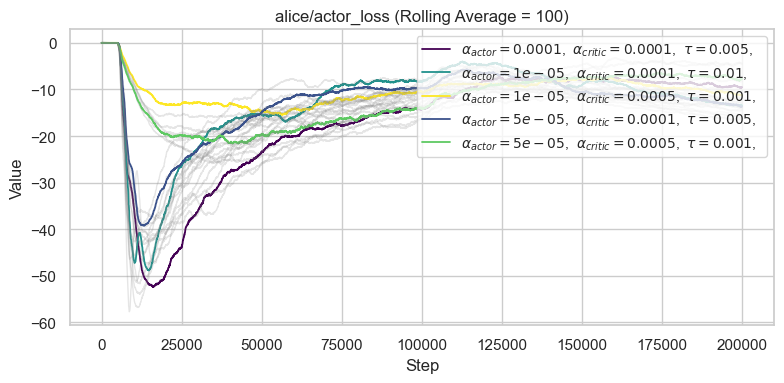

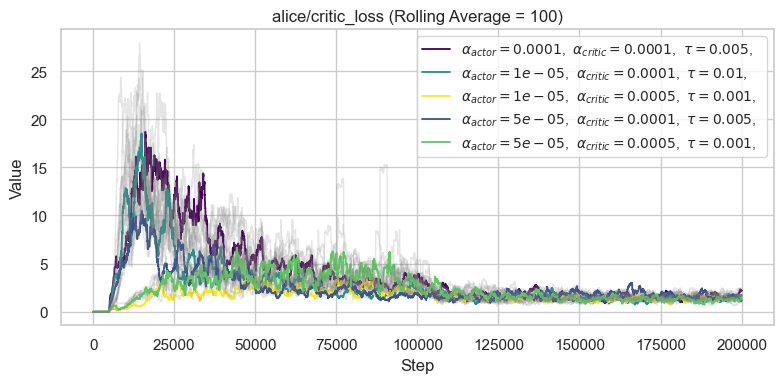

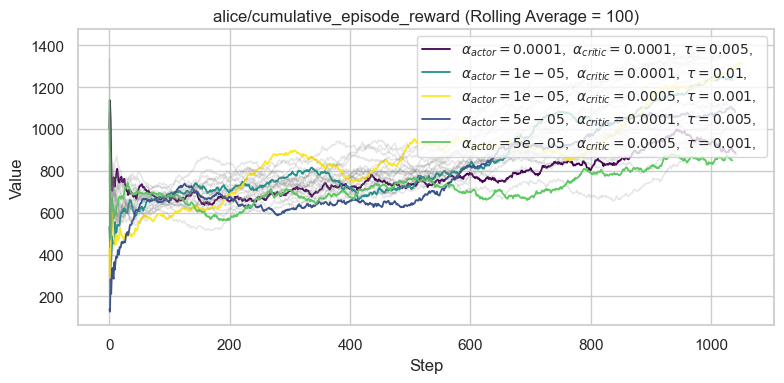

In [23]:
# Plotting data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

def format_run_label(run_name):
    import re

    def sci_fmt(x):
        return f"{float(x):.0e}" if "e" in x else x

    # Extract values using regex
    match = re.match(r"lra(.*?)_lrc(.*?)_gam(.*?)_tau(.*?)_b(\d+)", run_name)
    if not match:
        return run_name  # fallback

    lra, lrc, gamma, tau, bsz = match.groups()

    # Format using LaTeX math notation
    label = (
        rf"$\alpha_{{actor}}={sci_fmt(lra)}$,  "
        rf"$\alpha_{{critic}}={sci_fmt(lrc)}$,  "
        rf"$\tau={tau}$,  "
    )
    return label

# Load the data
df = pd.read_parquet(r"C:\Users\micha\Documents\master_thesis\combined_scalars.parquet")

# Set style
sns.set(style="whitegrid")

# Tags to plot
tags = [
    "alice/actor_loss",
    "alice/critic_loss",
    "alice/cumulative_episode_reward"
]

# Highlighted runs
highlight_runs = [
    "lra0.0001_lrc0.0001_gam0.95_tau0.005_b64",
    "lra5e-05_lrc0.0001_gam0.95_tau0.005_b64",
    "lra1e-05_lrc0.0001_gam0.95_tau0.01_b64",
    "lra5e-05_lrc0.0005_gam0.95_tau0.001_b64",
    "lra1e-05_lrc0.0005_gam0.95_tau0.001_b64"
]



# Generate a distinct color for each highlighted run
color_map = cm.get_cmap("viridis", len(highlight_runs))  # or use "tab20", "viridis", etc.
highlight_colors = {run: color_map(i) for i, run in enumerate(highlight_runs)}

# Rolling window
window = 100

# Plot each tag
for tag in tags:
    plt.figure(figsize=(8, 4))
    df_tag = df[df["tag"] == tag]

    for run_name, group in df_tag.groupby("run"):
        group_sorted = group.sort_values("step")
        rolling = group_sorted["value"].rolling(window=window, min_periods=1).mean()

        if run_name in highlight_runs:
            plt.plot(group_sorted["step"], rolling,
                        label=format_run_label(run_name),
                        alpha=1.0,
                        linewidth=1.3,
                        color=highlight_colors[run_name])
        else:
            plt.plot(group_sorted["step"], rolling,
                        alpha=0.2,
                        linewidth=1,
                        color='gray')

    plt.title(f"{tag} (Rolling Average = {window})")
    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.grid(True)

    if highlight_runs:
        plt.legend(loc="upper right",  fontsize="small")

    plt.tight_layout()
    plt.show()
